In [2]:
# Init the environment
import sys
import schemdraw
import schemdraw.elements as schemelem
import matplotlib
import matplotlib.pyplot as plt
import numpy
sys.path.insert(0, "../../..")

from init_physics_env import *

# Übung LB8
$$
\begin{align*}
U &\colonequals 20 \text{ V}
\end{align*}
$$

## a.
Ich bin zu inkompetent `schemdraw` zu nutzen

## b.
$$
\begin{align*}
I_0 &= 0,05 \text{ A} \\
R &= \frac{U}{I_0} \\
&= 400 ~\Omega
\end{align*}
$$

## c.
Die Stromstärke sinkt monoton mit steigender Frequenz, da durch die Erhöhung der Frequenz der induktive Widerstand der Spule steigt und somit bei gleicher Spannung weniger Elektronen durch den Leiterquerschnitt fließen.

## d.
$$
\begin{align*}
Z &= \frac{U_\text{eff}}{I_\text{eff}} \\
&= \sqrt{R^2 + X_L^2} \\
\rightarrow X_L &= \sqrt{ \frac{U_\text{eff}^2}{I_\text{eff}^2} - R^2 } \\
&= 2\pi fL \\
\rightarrow L &= \frac{\sqrt{U_\text{eff}^2-R^2I_\text{eff}^2}}{2\pi f I_\text{eff}} \\
\end{align*}
$$

In [3]:
U = 20
(I, f) = (Rational(15,1000), 400)
R = 400
Eq(Symbol('L'), (sqrt(U**2 - R**2 * I**2)/(2*pi*f*I)).evalf())

## e.
$$
\begin{align*}
\varphi &= \arccos\left( \frac{R}{Z} \right) \\
&= \arccos\left( \frac{R}{\sqrt{ R^2 + X_L^2 }} \right) \\
&= \arccos\left( \frac{R}{\sqrt{ R^2 + (2\pi fL)^2 }} \right) \\
\rightarrow (2\pi fL)^2 &= R^2\left(\frac1{\cos^2\varphi} - 1\right) \\
\rightarrow f &= \frac{\sqrt{R^2\left(\frac1{\cos^2\varphi} - 1\right)}}{2\pi L}
\end{align*}
$$

In [8]:
phi = rad(45)
Eq(Symbol('f'), (sqrt(R**2*(1/cos(phi)**2 - 1))/(2*pi*0.5)).evalf())

## f.
$$
\begin{align*}
Z &= \sqrt{R^2 + X_L^2} \\
&= \frac{U}{I} \\
\rightarrow I &= \frac{U}{\sqrt{R^2+X_L^2}} \\
&= \frac{U}{\sqrt{R^2+(2\pi f L)^2}} \\
\varphi &= \arccos \frac RZ \\
&= \arccos \frac{R}{\sqrt{R^2 + (2\pi f L)^2}}
\end{align*}
$$

In [9]:
(Eq(Symbol('I'), (20 / sqrt(R**2 + (2*pi*50*0.5)**2)).evalf()), Eq(Symbol('varphi'), deg(acos(R / sqrt(R**2 + (2*pi*50*0.5)**2))).evalf()))

## Zusatz
$$
\begin{align*}
U &= 20 \text{ V} \\
Z^2 &= R^2 + (2\pi f L)^2 \\
&= \frac{U^2}{I^2} \\
\rightarrow I(f) &= \frac{U}{\sqrt{R^2 + (2\pi f L)^2}}
\end{align*}
$$

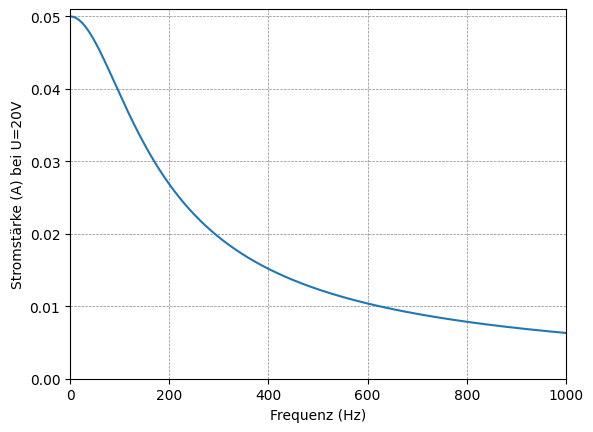

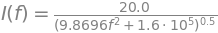

In [16]:
U = 20
R = 400
(I_L, f_L) = (Rational(15,1000), 400)
L = 0.5 # sqrt(U**2 - R**2 * I_L**2)/(2*pi*f_L*I_L)

plt.plot([(U / sqrt(R**2 + (2*pi*f*L)**2)).evalf() for f in range(1001)])
plt.ylabel("Stromstärke (A) bei U=20V")
plt.xlabel("Frequenz (Hz)")
plt.axis((0, 1000, 0, 0.051))
plt.grid(true, "major", "both", color='#888888', linestyle='--', linewidth=0.5)
plt.show()
Eq(Function('I')(Symbol('f')), (U / sqrt(R**2 + (2*pi*Symbol('f')*L)**2)).simplify().evalf(5))